In [24]:
import pandas as pd
import obspy
import numpy as np
import matplotlib.pyplot as plt
from obspy import UTCDateTime
import os

import random
import json
Dtmin_Noise=-25
Dtmax_Noise=-5
Dtmin_Pn=-5.
Dtmax_Pn=10.
Dtmin_Sn=-5.
Dtmax_Sn=10.

vLg_max=3.5
vLg_min=3.1
vLg=0.5*(vLg_max+vLg_min)
vPg_max=6.2
vPg_min=5.2
vPg=0.5*(vPg_max+vPg_min)
print(vPg)
#vPg=6.

tminCoda=300.
tmaxCoda=320.

5.7


In [25]:
from new_functions import *

Earthquake at 2023-06-16T16:38:28.069000Z with magnitude 4.8


Processing stations of ICGC: 100%|██████████| 25/25 [00:01<00:00, 14.58it/s]


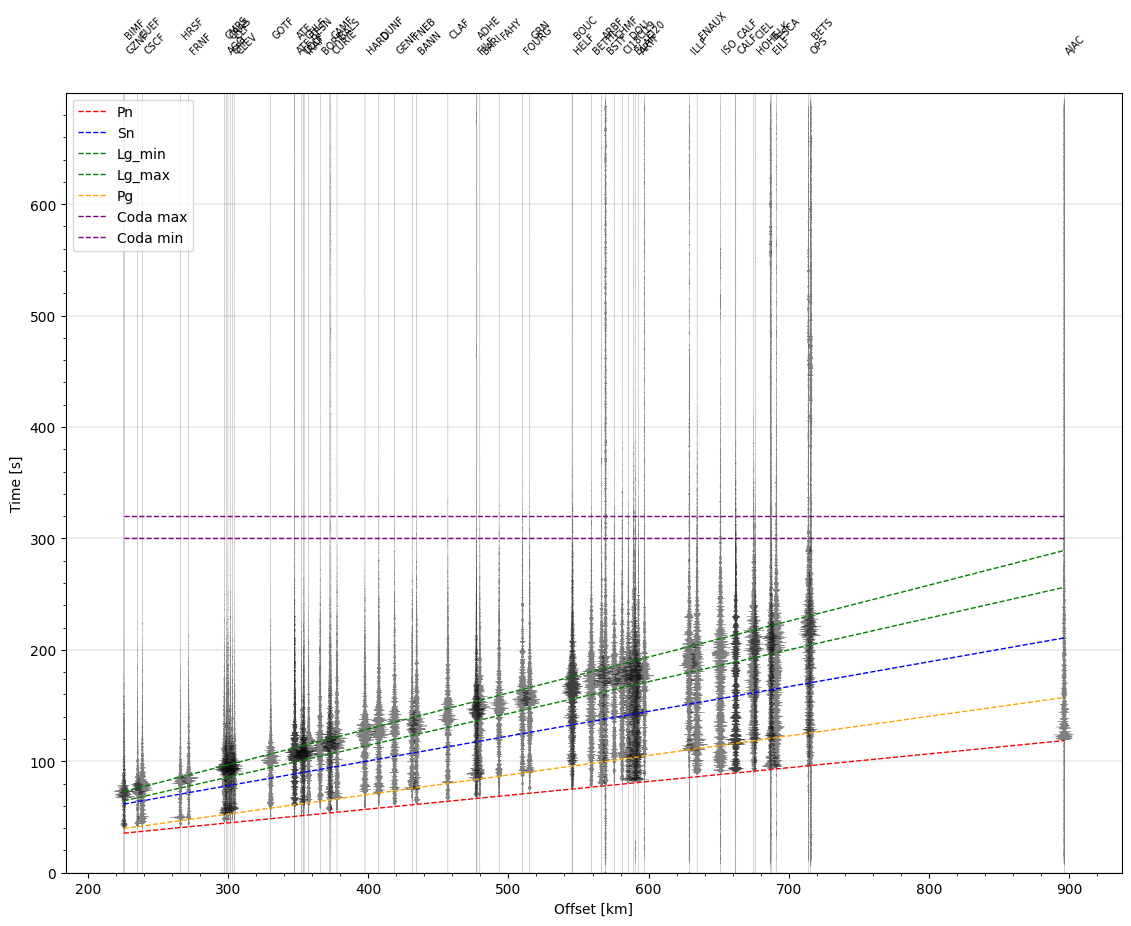

In [26]:
import warnings
warnings.filterwarnings("ignore")
datacenters =['RESIF','ODC','ETH','INGV','GEOFON', 'IRIS', 'ICGC']#,'BGR']
directory='/home/schreinl/Stage/Data/'
distmin=1.9
distmax=10.
catalogue_4_5 = pd.read_csv('/home/schreinl/Stage/Data/bigger_than_4.5.csv')

#catalogue_5 = pd.read_csv('/home/schreinl/Stage/Data/eq_4_france.csv')
#catalogue_5 = catalogue_5[catalogue_5['mag'] >= 4.0].reset_index(drop=True)
start = UTCDateTime(catalogue_4_5['time'][0])
end = start + 700
eq_lon = float(catalogue_4_5['longitude'][0])
eq_lat = float(catalogue_4_5['latitude'][0])
st_all, stations_all, plot = big_downloader2(datacenters, start, end, eq_lon, eq_lat, distmin, distmax, directory, plot=False)
time_string = UTCDateTime.strftime(start, format="%Y_%m_%dT%H_%M_%S")



st_plot_filt_all=st_all.copy()
fmin=3
fmax=6
st_plot_filt_all.filter("bandpass", freqmin=fmin, freqmax=fmax)


plot, st_Lg0 = plot_record_section(st_plot_filt_all[0:60], stations_all[0:60], eq_lat, 
eq_lon, start, tracehodo=True, v_Lg_min=vLg_min, v_Lg_max=vLg_max, 
v_Pg=vPg)


In [27]:
import obspy
from scipy.fftpack import hilbert
from scipy.signal import savgol_filter

import numpy as np
#from obspy.signal.filter import envelope
from scipy.signal import resample


def envelope_calculator(data):
    hilb = hilbert(data)
    data = (data ** 2 + hilb ** 2) ** 0.5
    return data


st_envelope = obspy.Stream()
smallest = 7000
for tr in st_plot_filt_all:
    data_envelope = envelope_calculator(tr.data)
    npts = tr.stats.npts
    if npts >= smallest:
        samprate = tr.stats.sampling_rate
        t = np.arange(0, npts / samprate, 1 / samprate)
        tr_envelope = obspy.Trace(data=data_envelope, header=tr.stats)
        #data_resampled = resample(tr_envelope.data, 10000)
        #tr_resampled = obspy.Trace(data=data_resampled, header=tr.stats)
        st_envelope.append(tr_envelope)

71
161
471


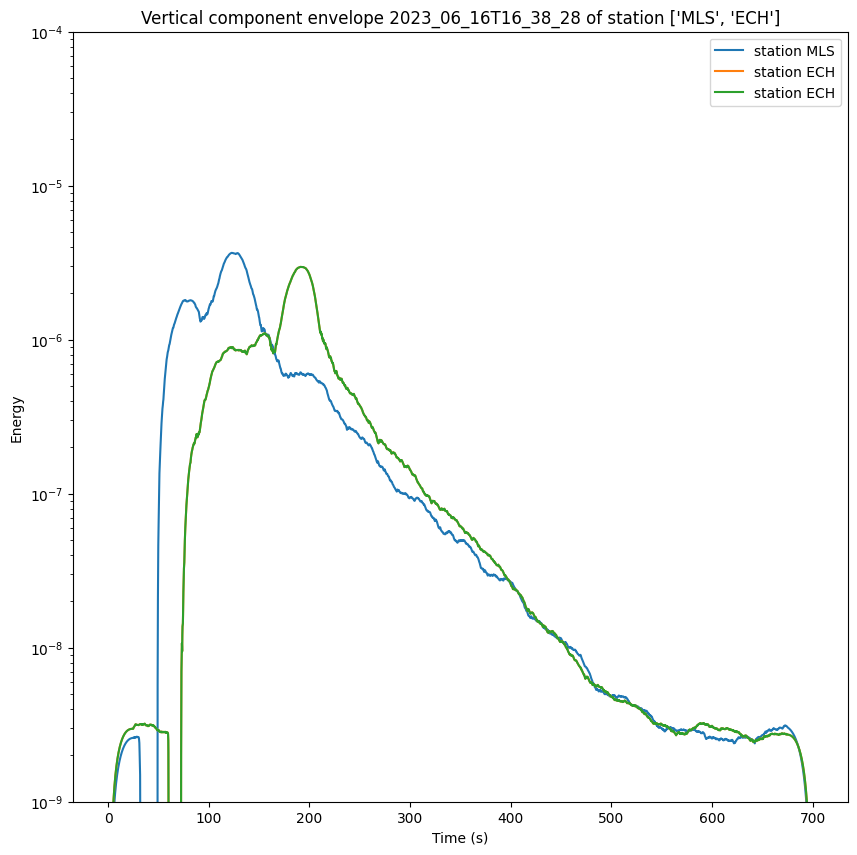

In [32]:
station = ["MLS","ECH"]
plt.figure(figsize=(10,10))
for i,tr in enumerate(st_envelope):
    if tr.stats.station == station[0] or tr.stats.station == station[1]:
        idx_reference = i
        print(i)
        npts = len(tr.data)
        samprate = tr.stats.sampling_rate #10000/700 
        t = np.arange(0, npts / samprate, 1 / samprate)

        #use a stable window length in s, while the window lenght in samples is dependant on the sample rate
        
        window_length = 50*samprate #min(2000, npts)
        if window_length % 2 == 0:
            window_length -= 1
        yhat = savgol_filter(tr.data, int(window_length), 3) 
        t = t[:len(yhat)]
        plt.title(f"Vertical component envelope {time_string} of station {station}")
        plt.ylabel("Energy")
        plt.xlabel("Time (s)")
        #plt.semilogy(t,st_envelope[i])
        plt.semilogy(t,yhat,label=f'station {tr.stats.station}')
        plt.ylim([1e-9,1e-4])
        #plt.xlim([100,350])
        plt.legend()
plt.show()

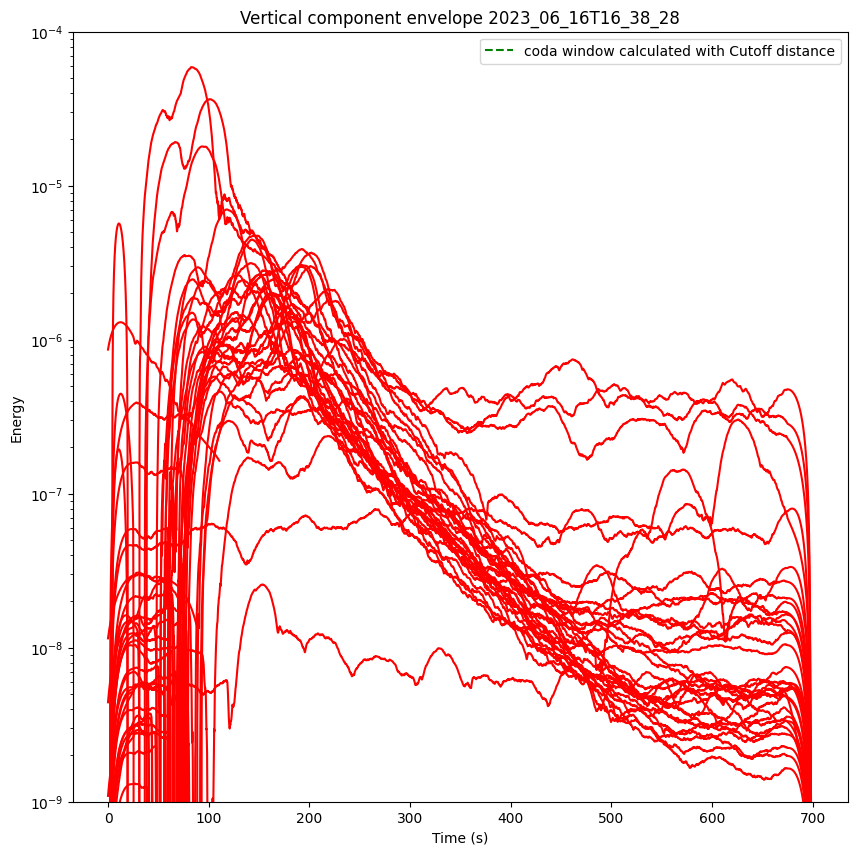

In [33]:
from scipy.signal import savgol_filter
from random import randint
def smooth_plot_envelope(time_string, n_traces,st_envelope, method='Cutoff distance',tmincoda_dist=None, tmaxcoda_dist=None,tmincoda_S = None, tmaxcoda_S= None,plotshow=False, savefig=True):
    testing = [(randint(1, len(st_plot_filt_all))) for i in range(n_traces)]

    plt.figure(figsize=(10,10))
    for i in testing:
        if i < len(st_envelope):
            npts = len(st_envelope[i].data)
            samprate = st_envelope[i].stats.sampling_rate #10000/700 
            t = np.arange(0, npts / samprate, 1 / samprate)

            #use a stable window length in s, while the window lenght in samples is dependant on the sample rate
            
            window_length = min(50*samprate, npts) # Ensure window_length is not greater than npts
            if window_length % 2 == 0:
                window_length -= 1
            yhat = savgol_filter(st_envelope[i].data, int(window_length), 3) 
            t = t[:len(yhat)]

            #plt.semilogy(t,st_envelope[i])
            plt.semilogy(t,yhat, color='red')
            plt.ylim([1e-9,1e-4])
            plt.title(f"Vertical component envelope {time_string}")
            plt.ylabel("Energy")
            plt.xlabel("Time (s)")
            #plt.xlim([100,350])
    plt.vlines(tmaxcoda_dist,ymax=1e-4,ymin=1e-9, label=f'coda window calculated with {method}',colors='g',linestyles='--')
    plt.vlines(tmincoda_dist,ymax=1e-4,ymin=1e-9,colors='g',linestyles='--')
    if tmincoda_S is not None and tmaxcoda_S is not None:
        plt.vlines(tmaxcoda_S,ymax=1e-4,ymin=1e-9, label='coda window calculated with S-wave',colors='b',linestyles='--')
        plt.vlines(tmincoda_S,ymax=1e-4,ymin=1e-9,colors='b',linestyles='--')
    #plt.vlines(350,ymax=1e-4,ymin=1e-9, label='coda window similar to Galina&Shapiro 2024',colors='b',linestyles='--')
    #plt.vlines(470,ymax=1e-4,ymin=1e-9,colors='b',linestyles='--')
    plt.legend()
    if savefig:
        mag_dir = '/home/schreinl/Stage/Data/Metadata/'
        with open(f"{mag_dir}{time_string}.txt", "r") as meta:
            for line in meta:
                if line.startswith("Magnitude:"):
                    magnitude = float(line.split(":")[1].strip())
        plt.savefig(f'/home/schreinl/Stage/Figures/SiteEffect/multiple_envelopes_{time_string}_{magnitude}_{method}_filtered.png', format='png')
    if plotshow:
        plt.show()
    
    return  
tset = smooth_plot_envelope(time_string, 50,st_envelope)

calculating SNR for Pn  phase
calculating SNR for Pg  phase
calculating SNR for Sn  phase
calculating SNR for Lg  phase
Reduced from   497  stations to   412  stations due to insufficient SNR or distance >  938.667022642586
coda window set from 344.17790830228154-394.17790830228154s based on Lg cutoff distance
plotting Lg_Coda amplitudes
calculating SNR for Pn  phase
calculating SNR for Pg  phase
calculating SNR for Sn  phase
calculating SNR for Lg  phase
Reduced from   497  stations to   412  stations due to insufficient SNR or distance >  938.667022642586
coda window set from 438.2939660453019-488.2939660453019s based on S wave arrival
plotting Lg_Coda amplitudes


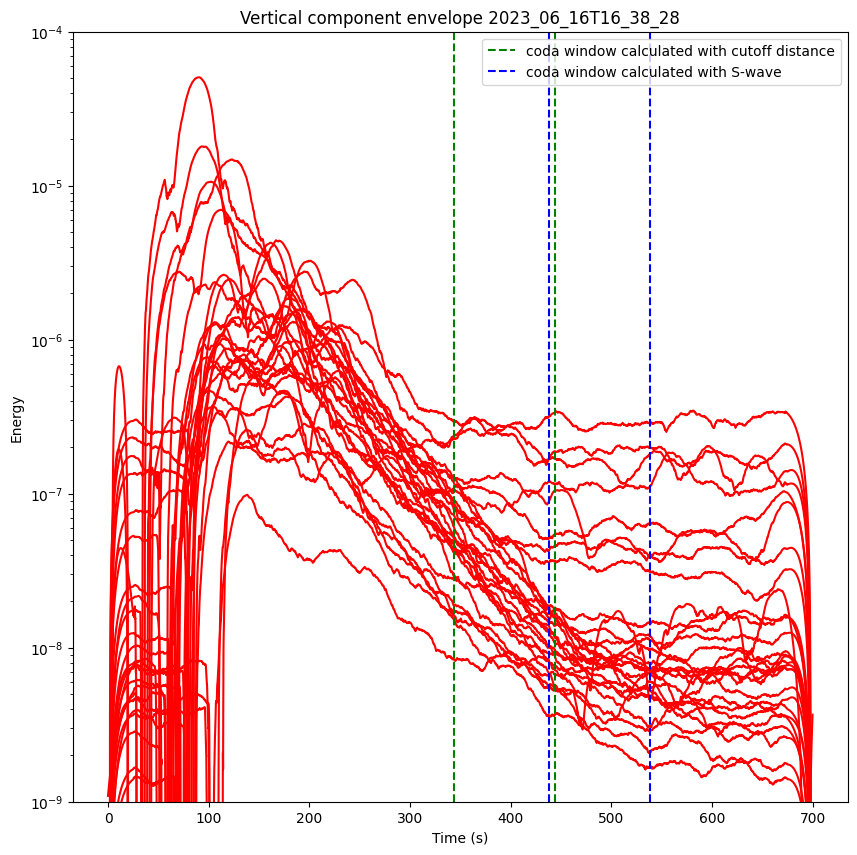

In [34]:
snr_threshold = 2
eq_start = start
stationref = "ECH"

filtered_stations_with_SNR, stations_with_SNR, distance_dict, tcoda_cutoff, filtered_st, stations_with_amps, amp_plot = SNR_all(stations_all, st_plot_filt_all, Dtmin_Pn, Dtmax_Pn, Dtmin_Sn, Dtmax_Sn, vLg_min,vLg_max,vPg_min, vPg_max, tminCoda, tmaxCoda,
         Dtmin_Noise, Dtmax_Noise,eq_start,eq_lat,eq_lon,snr_threshold=snr_threshold,plot_SNR=False,plot_amps=True, wavecode="Lg_Coda",dB=True,codawindow="cutoff",factor=1.1)


filtered_stations_with_SNR, stations_with_SNR, distance_dict, tcoda_S, filtered_st, stations_with_amps, amp_plot = SNR_all(stations_all, st_plot_filt_all, Dtmin_Pn, Dtmax_Pn, Dtmin_Sn, Dtmax_Sn, vLg_min,vLg_max,vPg_min, vPg_max, tminCoda, tmaxCoda,
         Dtmin_Noise, Dtmax_Noise,eq_start,eq_lat,eq_lon,snr_threshold=snr_threshold,plot_SNR=False,plot_amps=True, wavecode="Lg_Coda",dB=True,codawindow="S_phase", factor=2)

#print(filtered_stations_with_SNR)
for i,tr in enumerate(st_envelope):
    if tr.stats.station == stationref:
        idx_reference = i


filtered_station_names = set(row[1] for row in filtered_stations_with_SNR) 
filtered_smooth_stream = obspy.Stream()
filtered_stream = obspy.Stream()

for trace in st_envelope:
    if trace.stats.station in filtered_station_names:
        filtered_stream.append(trace)




for i,tr in enumerate(filtered_stream):
    if tr.stats.station == stationref:
        idx_reference = i


plot_filtered_smoothed = smooth_plot_envelope(time_string, 50,filtered_stream,method="cutoff distance",
                    tmincoda_dist=tcoda_cutoff, tmaxcoda_dist=tcoda_cutoff+100, tmincoda_S=tcoda_S, tmaxcoda_S=tcoda_S+100, savefig=False)

In [49]:
eq_list = pd.read_csv('/home/schreinl/Stage/Data/trial.csv')
eq_list = pd.read_csv('/home/schreinl/Stage/Data/bigger_than_4.5.csv')

amplitudes_dict = {}

for i in range(len(eq_list)):
    start = UTCDateTime(eq_list["time"][i])
    time_string = UTCDateTime.strftime(start, format="%Y_%m_%dT%H_%M_%S")
    magnitude = eq_list["mag"][i]
    
    try:
        with open(f"/home/schreinl/Stage/Data/{time_string}/{time_string}_envelope_amps_cutoff_fac_1.1_dict.txt", "r") as file:
            amp_dict = json.load(file)

        for station, data in amp_dict.items():
            if station not in amplitudes_dict:
                amplitudes_dict[station] = [None] * i 
            amplitudes_dict[station].append({"amplitude": data["amplitude"], "time": time_string, "magnitude": magnitude})
        
        for station in amplitudes_dict:
            if station not in amp_dict:
                amplitudes_dict[station].append(None)
    except FileNotFoundError:
        for station in amplitudes_dict:
            amplitudes_dict[station].append(None)

#print(amplitudes_dict['ECH'])


### Find fitting Reference station

In [50]:
from obspy.clients.fdsn import Client
import folium

client = Client("RESIF")
network = "*"
stations = ["SSB", "ECH", "CHIF", "BALS", "MLS", "CLF", "OGMO", "EUCT"]

inventory = client.get_stations(network=network, station=",".join(stations), level="station")

origin = [47, 9]
zoom = 5

carte = folium.Map(location=origin, zoom_start=zoom)

for network in inventory:
    for station in network:
        lat = station.latitude
        lon = station.longitude
        name = station.code
        infos = f"{name} ({lat}, {lon})"
        folium.Marker(
            location=[lat, lon],
            tooltip=infos,
            icon=folium.Icon(color='blue', icon='info-sign')
        ).add_to(carte)

carte


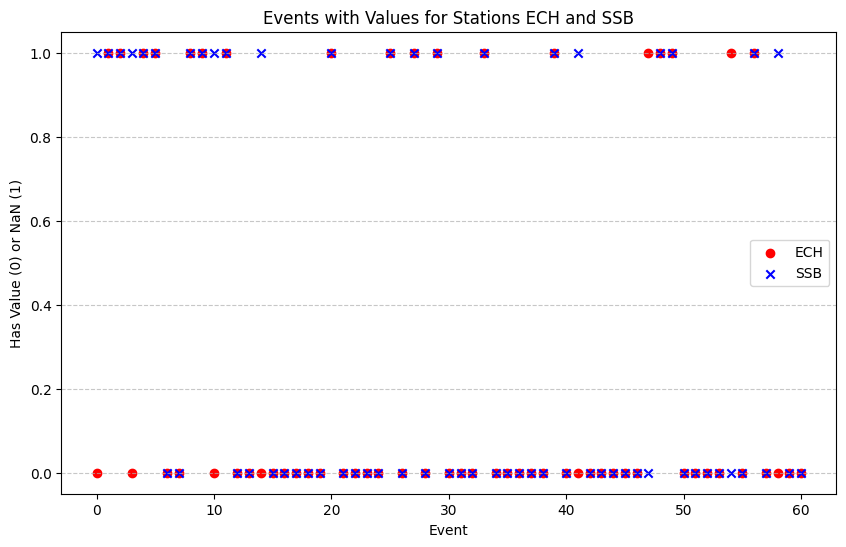

In [51]:


station2 = "SSB"
fallback_station = "ECH"
amplitude_ratios = {}

# Counters for stations with and without valid ratios
total_stations = len(amplitudes_dict.keys())
stations_with_no_valid_ratio = 0

events = range(len(amplitudes_dict[station2]))
ech_values = np.array([entry['amplitude'] if entry is not None else None for entry in amplitudes_dict[fallback_station]], dtype=np.float64)
ssb_values = np.array([entry['amplitude'] if entry is not None else None for entry in amplitudes_dict[station2]], dtype=np.float64)

ech_values = np.where(ech_values == None, np.nan, ech_values)
ssb_values = np.where(ssb_values == None, np.nan, ssb_values)

plt.figure(figsize=(10, 6))
plt.scatter(events, np.isnan(ech_values), label='ECH', marker='o', color='r')
plt.scatter(events, np.isnan(ssb_values), label='SSB', marker='x', color='b')

plt.xlabel("Event")
plt.ylabel("Has Value (0) or NaN (1)")
plt.title("Events with Values for Stations ECH and SSB")
plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()

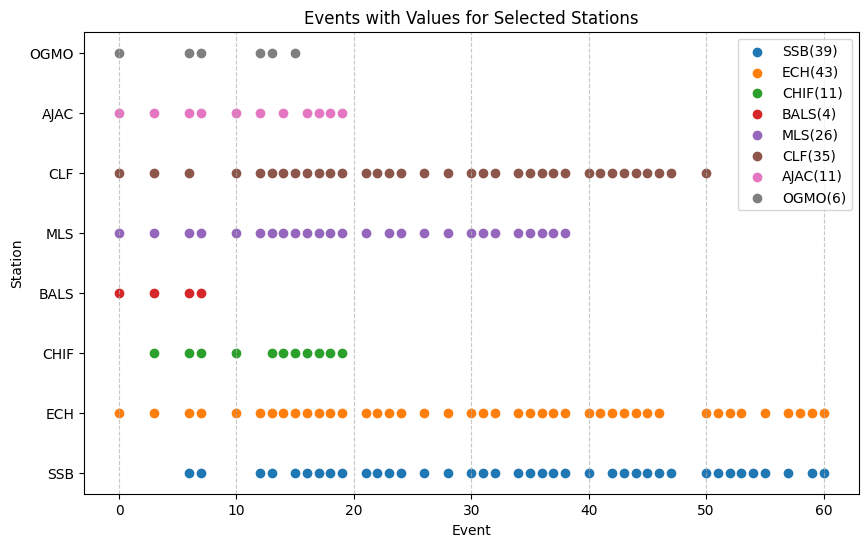

In [52]:
stations_to_plot = ["SSB", "ECH", "CHIF", "BALS", "MLS", "CLF", 'AJAC', "OGMO"]
events = range(len(amplitudes_dict[station2]))

plt.figure(figsize=(10, 6))

for i, station in enumerate(stations_to_plot):
    values = np.array([entry['amplitude'] if entry is not None else None for entry in amplitudes_dict[station]], dtype=np.float64)
    values = np.where(values == None, np.nan, values)
    event_indices = [event for event, value in enumerate(values) if not np.isnan(value)]
    count = len(event_indices)
    plt.scatter(event_indices, [i] * len(event_indices), label=f"{station}({count})", marker='o')

plt.xlabel("Event")
plt.ylabel("Station")
plt.yticks(range(len(stations_to_plot)), stations_to_plot)
plt.title("Events with Values for Selected Stations")
plt.legend(loc='upper right')
plt.grid(axis="x", linestyle="--", alpha=0.7)
plt.show()

In [53]:
import random

station_tests = random.sample(list(amplitudes_dict.keys()), 25)
'''
amplitudes_dict_sample = {station: [] for station in station_tests}

for i in range(len(eq_list)):
    start = UTCDateTime(eq_list["time"][i])
    time_string = UTCDateTime.strftime(start, format="%Y_%m_%dT%H_%M_%S")
    
    try:
        with open(f"/home/schreinl/Stage/Data/{time_string}/{time_string}_envelope_amps_fac_1.5_dict.txt", "r") as file:
            amp_dict = json.load(file)

        for station in station_tests:
            if station in amp_dict:
                amplitudes_dict[station].append((time_string, amp_dict[station]["amplitude"]))
            else:
                amplitudes_dict[station].append((time_string, None))
    except FileNotFoundError:
        for station in station_tests:
            amplitudes_dict[station].append((time_string, None))

print(len(amplitudes_dict_sample))
'''

'\namplitudes_dict_sample = {station: [] for station in station_tests}\n\nfor i in range(len(eq_list)):\n    start = UTCDateTime(eq_list["time"][i])\n    time_string = UTCDateTime.strftime(start, format="%Y_%m_%dT%H_%M_%S")\n    \n    try:\n        with open(f"/home/schreinl/Stage/Data/{time_string}/{time_string}_envelope_amps_fac_1.5_dict.txt", "r") as file:\n            amp_dict = json.load(file)\n\n        for station in station_tests:\n            if station in amp_dict:\n                amplitudes_dict[station].append((time_string, amp_dict[station]["amplitude"]))\n            else:\n                amplitudes_dict[station].append((time_string, None))\n    except FileNotFoundError:\n        for station in station_tests:\n            amplitudes_dict[station].append((time_string, None))\n\nprint(len(amplitudes_dict_sample))\n'

In [54]:
for station in amplitudes_dict:
    amplitudes = amplitudes_dict[station]
    recorded_count = sum(amp is not None for amp in amplitudes)
    total_events = len(amplitudes_dict["ECH"])  
    
    #print(f"Station {station} recorded {recorded_count} earthquakes out of {total_events}")



Mean Ratio (ECH / SSB): 1.14374
Standard Deviation: 0.27849
Median: 1.09258
Min Ratio: 0.68191
Max Ratio: 2.32563


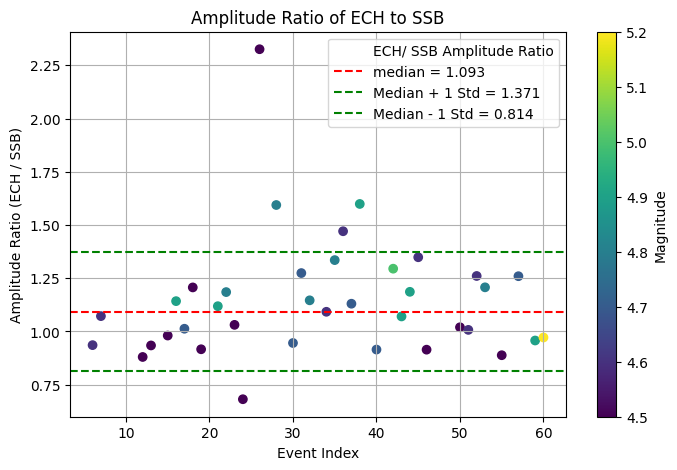

In [55]:
station1 = "ECH"
station2 = "SSB"

denom_amplitudes = np.array([entry['amplitude'] if entry is not None else None for entry in amplitudes_dict[station1]], dtype=np.float64)
counter_amplitudes = np.array([entry['amplitude'] if entry is not None else None for entry in amplitudes_dict[station2]], dtype=np.float64)

denom_amplitudes = np.where(denom_amplitudes == None, np.nan, denom_amplitudes)
counter_amplitudes = np.where(counter_amplitudes == None, np.nan, counter_amplitudes)
#here we have to read in the noise values, for which we calculate the SNR to then filter out stations for which we can potentially not calculate
# a
ratio = np.divide(denom_amplitudes, counter_amplitudes, out=np.full_like(denom_amplitudes, np.nan), where=(counter_amplitudes != 0))
valid_ratios = ratio[~np.isnan(ratio)]
mean_ratio = np.nanmean(valid_ratios)
std_ratio = np.nanstd(valid_ratios)
median_ratio = np.nanmedian(valid_ratios)
min_ratio = np.nanmin(valid_ratios)
max_ratio = np.nanmax(valid_ratios)

magnitudes = np.array([entry['magnitude'] if entry is not None else None for entry in amplitudes_dict[station1]], dtype=np.float64)
magnitudes = np.where(magnitudes == None, np.nan, magnitudes)

print(f"Mean Ratio ({station1} / {station2}): {mean_ratio:.5f}")
print(f"Standard Deviation: {std_ratio:.5f}")
print(f"Median: {median_ratio:.5f}")
print(f"Min Ratio: {min_ratio:.5f}")
print(f"Max Ratio: {max_ratio:.5f}")

plt.figure(figsize=(8, 5))
sc = plt.scatter(range(len(ratio)), ratio, c=magnitudes, cmap='viridis', marker="o", label=f"{station1}/ {station2} Amplitude Ratio")
plt.colorbar(sc, label='Magnitude')
plt.axhline(median_ratio, color="r", linestyle="--", label=f"median = {median_ratio:.3f}")
plt.axhline(median_ratio + std_ratio, color="g", linestyle="--", label=f"Median + 1 Std = {median_ratio + std_ratio:.3f}")
plt.axhline(median_ratio - std_ratio, color="g", linestyle="--", label=f"Median - 1 Std = {median_ratio - std_ratio:.3f}")

plt.xlabel("Event Index")
plt.ylabel(f"Amplitude Ratio ({station1} / {station2})")
plt.title(f"Amplitude Ratio of {station1} to {station2}")
plt.legend()
plt.grid(True)
plt.show()


Total number of stations: 1611
Number of stations with no valid ratio: 138


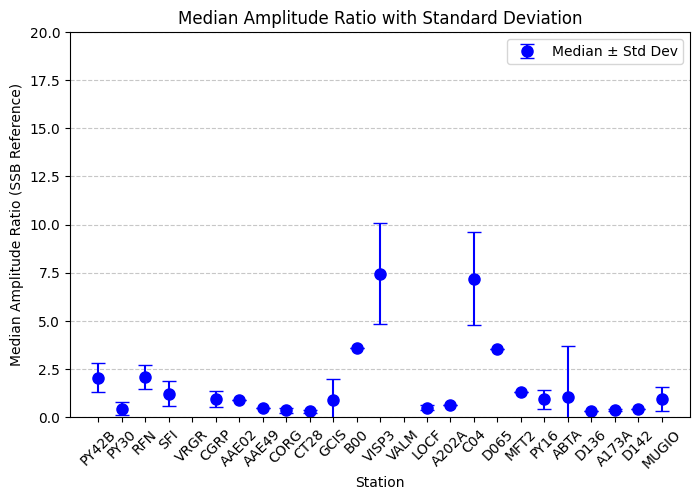

In [56]:

import random

station2 = "SSB"
fallback_station = "ECH"
amplitude_ratios = {}

total_stations = len(amplitudes_dict.keys())
stations_with_no_valid_ratio = 0

for station1 in amplitudes_dict.keys():
    denom_amplitudes = np.array([entry['amplitude'] if entry is not None else None for entry in amplitudes_dict[station1]], dtype=np.float64)
    counter_amplitudes = np.array([entry['amplitude'] if entry is not None else None for entry in amplitudes_dict[station2]], dtype=np.float64)

    denom_amplitudes = np.where(denom_amplitudes == None, np.nan, denom_amplitudes)
    counter_amplitudes = np.where(counter_amplitudes == None, np.nan, counter_amplitudes)

    if np.isnan(counter_amplitudes).all():
        print(f"Using fallback station {fallback_station} for station {station1}")
        counter_amplitudes = np.array([entry['amplitude'] if entry is not None else None for entry in amplitudes_dict[fallback_station]], dtype=np.float64)
        counter_amplitudes = np.where(counter_amplitudes == None, np.nan, counter_amplitudes)

    ratio = np.divide(denom_amplitudes, counter_amplitudes, out=np.full_like(denom_amplitudes, np.nan), where=(counter_amplitudes != 0))
    valid_ratios = ratio[~np.isnan(ratio)]
    
    if len(valid_ratios) > 0:
        amplitude_ratios[station1] = {
            "median": np.nanmedian(valid_ratios),
            "std": np.nanstd(valid_ratios),
        }
    else:
        amplitude_ratios[station1] = {
            "median": np.nan,
            "std": np.nan,
        }
        #print(f"No valid ratio computed for station {station1}")
        stations_with_no_valid_ratio += 1

print(f"Total number of stations: {total_stations}")
print(f"Number of stations with no valid ratio: {stations_with_no_valid_ratio}")

stations_list = list(amplitude_ratios.keys())
station_tests = random.sample(list(amplitudes_dict.keys()), 25)
median_values = [amplitude_ratios[st]["median"] for st in station_tests]
std_values = [amplitude_ratios[st]["std"] for st in station_tests]

plt.figure(figsize=(8, 5))
plt.errorbar(station_tests, median_values, yerr=std_values, fmt='o', capsize=5, markersize=8, color="b", label="Median ± Std Dev")

plt.xlabel("Station")
plt.ylabel(f"Median Amplitude Ratio ({station2} Reference)")
plt.title(f"Median Amplitude Ratio with Standard Deviation")
plt.legend()
plt.ylim(0, 20)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.xticks(rotation=45)
plt.show()

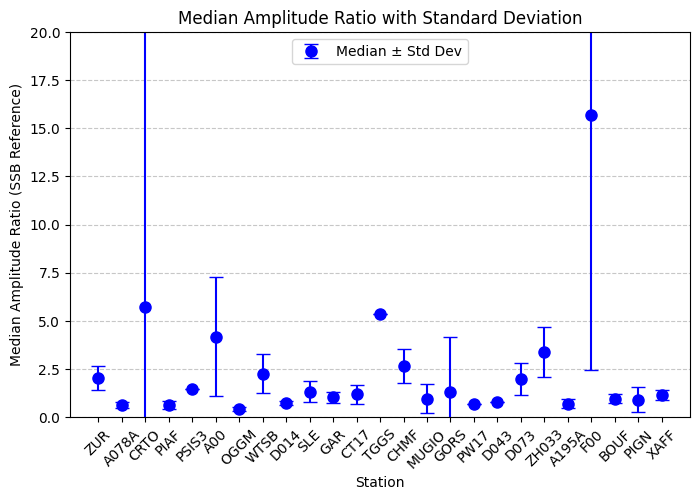

In [39]:
station2 = "SSB"
amplitude_ratios = {}

for station1 in amplitudes_dict.keys():
    denom_amplitudes = np.array(amplitudes_dict[station1], dtype=np.float64)
    counter_amplitudes = np.array(amplitudes_dict[station2], dtype=np.float64)

    denom_amplitudes = np.where(denom_amplitudes == None, np.nan, denom_amplitudes)
    counter_amplitudes = np.where(counter_amplitudes == None, np.nan, counter_amplitudes)

    ratio = np.divide(denom_amplitudes, counter_amplitudes, out=np.full_like(denom_amplitudes, np.nan), where=(counter_amplitudes != 0))
    valid_ratios = ratio[~np.isnan(ratio)]
    
    if len(valid_ratios) > 0:
        amplitude_ratios[station1] = {
            "median": np.nanmedian(valid_ratios),
            "std": np.nanstd(valid_ratios),
        }
    else:
        amplitude_ratios[station1] = {
            "median": np.nan,
            "std": np.nan,
        }

stations_list = list(amplitude_ratios.keys())
station_tests = random.sample(list(amplitudes_dict.keys()), 25)
median_values = [amplitude_ratios[st]["median"] for st in station_tests]
std_values = [amplitude_ratios[st]["std"] for st in station_tests]

plt.figure(figsize=(8, 5))
plt.errorbar(station_tests, median_values, yerr=std_values, fmt='o', capsize=5, markersize=8, color="b", label="Median ± Std Dev")

plt.xlabel("Station")
plt.ylabel(f"Median Amplitude Ratio ({station2} Reference)")
plt.title(f"Median Amplitude Ratio with Standard Deviation")
plt.legend()
plt.ylim(0, 20)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.xticks(rotation=45)
plt.show()


25


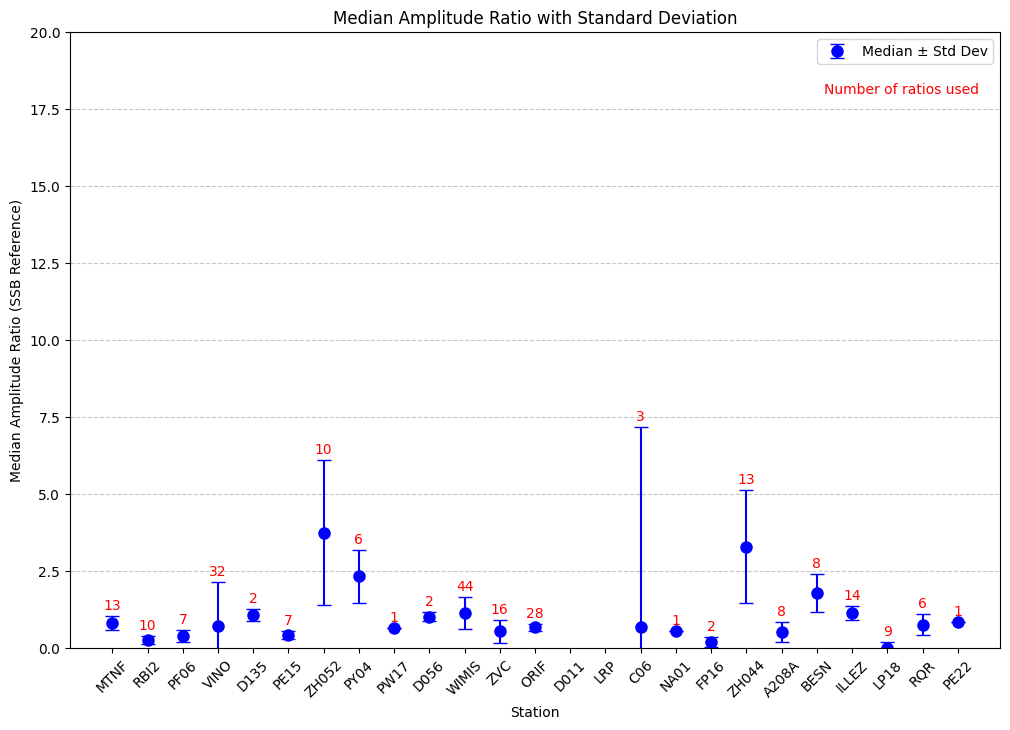

In [18]:
station_tests = random.sample(list(amplitudes_dict.keys()), 25)
print(len(station_tests))
plt.figure(figsize=(12, 8))

for i, station in enumerate(station_tests):
    median = amplitude_ratios[station]["median"]
    std = amplitude_ratios[station]["std"]
    
    denom_amplitudes = np.array([entry['amplitude'] if entry is not None else None for entry in amplitudes_dict[station]], dtype=np.float64)
    counter_amplitudes = np.array([entry['amplitude'] if entry is not None else None for entry in amplitudes_dict[station2]], dtype=np.float64)

    denom_amplitudes = np.where(denom_amplitudes == None, np.nan, denom_amplitudes)
    counter_amplitudes = np.where(counter_amplitudes == None, np.nan, counter_amplitudes)

    ratio = np.divide(denom_amplitudes, counter_amplitudes, out=np.full_like(denom_amplitudes, np.nan), where=(counter_amplitudes != 0))
    valid_ratios = ratio[~np.isnan(ratio)]
    
    count = len(valid_ratios)
    
    plt.errorbar(station, median, yerr=std, fmt='o', capsize=5, markersize=8, color="b", label="Median ± Std Dev" if i == 0 else "")
    plt.text(i, median + std + 0.2, f"{count}", ha="center", fontsize=10, color="red")

plt.xticks(rotation=45)
plt.xlabel("Station")
plt.ylim(0, 20)
plt.ylabel(f"Median Amplitude Ratio ({station2} Reference)")
plt.title(f"Median Amplitude Ratio with Standard Deviation")
plt.legend(loc="upper right")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.text(24.6, 18, "Number of ratios used", color="red", ha="right", fontsize=10)
plt.show()


Total number of stations: 1770
Number of stations with no valid ratio: 93


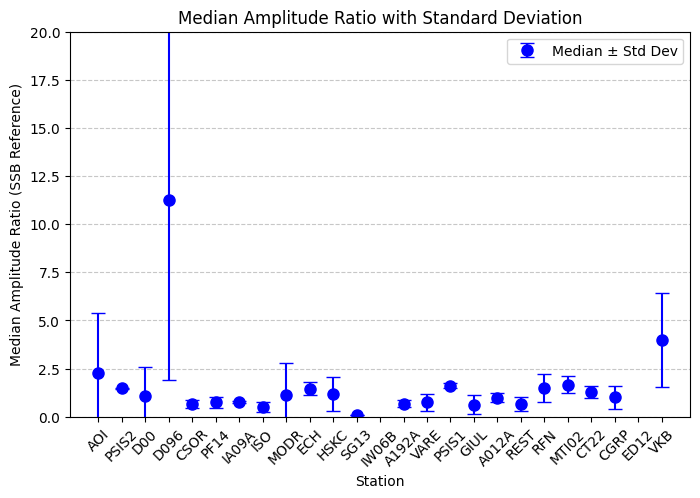

In [58]:
def site_effect(eq_file='/home/schreinl/Stage/Data/eq_4_france.csv', codafile='envelope_amps_fac_1.5_dict',sample_size=25,ref_station1 = "SSB", ref_station2 = "ECH", ratio_plot = False):
    '''
    Function calculates the site effect for each station by building the median amplitude ratio of each station to the reference station.
    For each event and for each station the site effect is calculated.
    output should be one large
    Inputs: earthquakes in a list, codafile which is the ending of the files that contain the amplitudes
    Output: a dictionary with the site effect for each station

    '''

    #read in the earthquake list
    eq_list = pd.read_csv(eq_file)

    #create the dictionary
    amplitudes_dict = {}

    #fill the dict with the amplitudes, so for a specific coda window file the amplitudes are read in
    for i in range(len(eq_list)):
        start = UTCDateTime(eq_list["time"][i])
        time_string = UTCDateTime.strftime(start, format="%Y_%m_%dT%H_%M_%S")
        
        try:    #/home/schreinl/Stage/Data/{time_string}/{time_string}_envelope_amps_fac_1.5_dict.txt
            with open(f"/home/schreinl/Stage/Data/{time_string}/{time_string}_{codafile}.txt", "r") as file:
                amp_dict = json.load(file)

            for station, data in amp_dict.items():
                if station not in amplitudes_dict:
                    amplitudes_dict[station] = [None] * i 
                amplitudes_dict[station].append(data["amplitude"])
            
            for station in amplitudes_dict:
                if station not in amp_dict:
                    amplitudes_dict[station].append(None)
        except FileNotFoundError:
            for station in amplitudes_dict:
                amplitudes_dict[station].append(None)

        #so now we have a dictionary with the amplitudes for each station for each event, so dimensions are N number of events given,
        # and M number of stations that have recorded at least one event

    # if we wanted to test what we did, we use a smaller batch size of stations
    sample_size = min(sample_size, len(amplitudes_dict.keys()))
    station_tests = random.sample(list(amplitudes_dict.keys()), sample_size)

    #here we choose the reference stations
    station2 = ref_station1
    fallback_station = ref_station2
    amplitude_ratios = {}

    # Counters for stations with and without valid ratios
    total_stations = len(amplitudes_dict.keys())
    stations_with_no_valid_ratio = 0

    for station1 in amplitudes_dict.keys():
        denom_amplitudes = np.array(amplitudes_dict[station1], dtype=np.float64)
        counter_amplitudes = np.array(amplitudes_dict[station2], dtype=np.float64)

        # Replace None with np.nan
        denom_amplitudes = np.where(denom_amplitudes == None, np.nan, denom_amplitudes)
        counter_amplitudes = np.where(counter_amplitudes == None, np.nan, counter_amplitudes)

        # Check if the reference station has missing values and use fallback if necessary
        
        # Check if the reference station has missing values and use fallback if necessary
        if np.isnan(counter_amplitudes).all():
            print(f"Using fallback station {fallback_station} for station {station1}")
            counter_amplitudes = np.array(amplitudes_dict[fallback_station], dtype=np.float64)
            counter_amplitudes = np.where(counter_amplitudes == None, np.nan, counter_amplitudes)

        # Calculate the ratio
        ratio = np.divide(denom_amplitudes, counter_amplitudes, out=np.full_like(denom_amplitudes, np.nan), where=(counter_amplitudes != 0))
        valid_ratios = ratio[~np.isnan(ratio)]
        
        if len(valid_ratios) > 0:
            amplitude_ratios[station1] = {
                "median": np.nanmedian(valid_ratios),
                "std": np.nanstd(valid_ratios),
            }
        else:
            amplitude_ratios[station1] = {
                "median": np.nan,
                "std": np.nan,
            }
            #print(f"No valid ratio computed for station {station1}")
            stations_with_no_valid_ratio += 1

    # Print the number of stations with no valid ratio and the total number of stations
    print(f"Total number of stations: {total_stations}")
    print(f"Number of stations with no valid ratio: {stations_with_no_valid_ratio}")

    if ratio_plot == True:
        station_tests = random.sample(list(amplitudes_dict.keys()), 25)
        median_values = [amplitude_ratios[st]["median"] for st in station_tests]
        std_values = [amplitude_ratios[st]["std"] for st in station_tests]

        plt.figure(figsize=(8, 5))
        plt.errorbar(station_tests, median_values, yerr=std_values, fmt='o', capsize=5, markersize=8, color="b", label="Median ± Std Dev")

        plt.xlabel("Station")
        plt.ylabel(f"Median Amplitude Ratio ({station2} Reference)")
        plt.title(f"Median Amplitude Ratio with Standard Deviation")
        plt.legend()
        plt.ylim(0, 20)
        plt.grid(axis="y", linestyle="--", alpha=0.7)
        plt.xticks(rotation=45)
        plt.show()

    return amplitude_ratios
        
    
amplitude_ratio = site_effect(eq_file='/home/schreinl/Stage/Data/eq_4_france.csv', codafile='envelope_amps_fac_1.5_dict',sample_size=25,ref_station1 = "SSB", ref_station2 = "ECH", ratio_plot = True)